In [1]:
# 必要なライブラリのimport（変更しないでください）
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split

# DataFrameですべての列を表示する設定（変更しないでください）
pd.options.display.max_columns = None

In [2]:
# seabornからtitanicのデータセットを読み込む（変更しないでください）
dataset = sns.load_dataset("titanic")

In [3]:
# TensorFlow / Keras のインポート
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# 1. 問題設定
# titanicデータセットを用いて「乗客が生存したかどうか（survived）」を二値分類で予測する

# 2. データ確認
print(dataset.head())
print(dataset.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64

In [5]:
# 3. 特徴量と目的変数の選択
# 目的変数: survived（0:死亡, 1:生存）
target_col = "survived"

# 使用する特徴量（数値＋カテゴリ）
feature_cols = [
    "pclass",   # 客室クラス
    "sex",      # 性別
    "age",      # 年齢
    "sibsp",    # 同乗している兄弟/配偶者の数
    "parch",    # 同乗している親/子供の数
    "fare",     # 運賃
    "embarked", # 乗船港
    "alone"     # 一人かどうか
]

data = dataset[feature_cols + [target_col]].copy()

In [ ]:
# 4. 欠損値の処理（単純に欠損行を削除）
data = data.dropna()

X shape: (712, 9)
y shape: (712,)


In [ ]:
# 5. カテゴリ変数のダミー変数化
data_encoded = pd.get_dummies(
    data,
    columns=["sex", "embarked", "alone"],
    drop_first=True)

In [12]:
# 6. 説明変数Xと目的変数yの分割
X = data_encoded.drop(columns=[target_col])
y = data_encoded[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (712, 9)
y shape: (712,)


In [13]:
# 7. 学習データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# 8. 特徴量の標準化（ニューラルネットの学習を安定させるため）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# 9. ディープラーニングモデルの定義（Keras Sequential API）
input_dim = X_train_scaled.shape[1]

model = Sequential([
    Dense(16, activation="relu", input_shape=(input_dim,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")  # 二値分類なので出力は1ユニット＋sigmoid
])

model.summary()

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 10. コンパイル
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [17]:
# 11. 学習の実行
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6989 - loss: 0.6520 - val_accuracy: 0.6491 - val_loss: 0.6438
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7275 - loss: 0.6082 - val_accuracy: 0.6491 - val_loss: 0.6205
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7451 - loss: 0.5752 - val_accuracy: 0.6930 - val_loss: 0.6019
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7736 - loss: 0.5492 - val_accuracy: 0.7281 - val_loss: 0.5842
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7890 - loss: 0.5280 - val_accuracy: 0.7456 - val_loss: 0.5710
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8022 - loss: 0.5106 - val_accuracy: 0.7544 - val_loss: 0.5626
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8066 - loss: 0.4961 - val_accuracy: 0.7719 - val_loss: 0.5547
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8066 - loss: 0.4843 - val_accuracy: 0.7895 - va

In [18]:
# 12. テストデータでの評価
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4484
Test Accuracy: 0.8112


In [19]:
# 13. 予測と詳細評価
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int).reshape(-1)

print("Accuracy (sklearn):", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Accuracy (sklearn): 0.8111888111888111
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85        85
           1       0.79      0.72      0.76        58

    accuracy                           0.81       143
   macro avg       0.81      0.80      0.80       143
weighted avg       0.81      0.81      0.81       143

Confusion Matrix:
[[74 11]
 [16 42]]


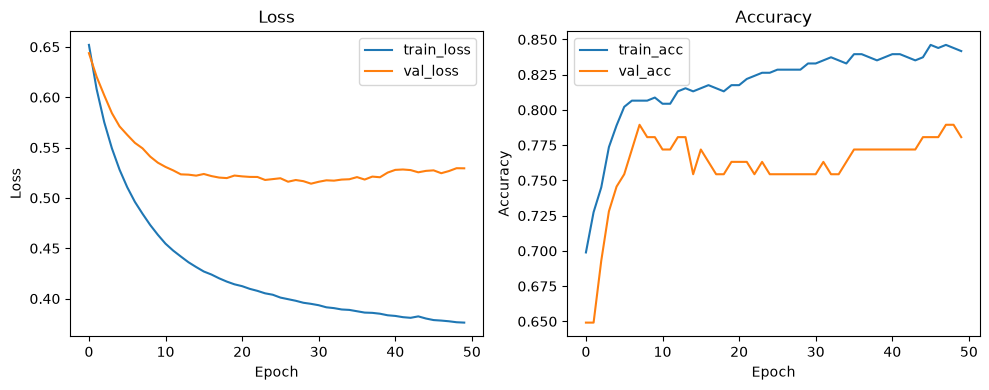

In [20]:
# 14. 学習過程の可視化（任意）
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()